<a href="https://colab.research.google.com/github/justunforgettable/Plant_Disease_Detector/blob/main/Plant_disease_detector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install opendatasets --quiet

import opendatasets as od          # for downloading dataset from Kaggle
import tensorflow as tf            # the main deep learning library
from tensorflow import keras       # keras is the easy layer on top of tensorflow
from tensorflow.keras import layers# all the layer types: Conv2D, Dense, etc.
from tensorflow.keras.preprocessing.image import ImageDataGenerator  # loads images from folders

import numpy as np                 # for array math
import matplotlib.pyplot as plt    # for plotting graphs and showing images
import os                          # for working with file paths and folders
import warnings
warnings.filterwarnings('ignore')  # hide unimportant warnings

# Check TensorFlow version (should be 2.x)
print("TensorFlow version:", tf.__version__)
print("Setup complete! Ready to go.")



TensorFlow version: 2.20.0
Setup complete! Ready to go.


In [3]:

od.download("https://www.kaggle.com/datasets/emmarex/plantdisease")
print("Dataset downloaded!")


Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: nahidkausar
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease


100%|██████████| 658M/658M [00:31<00:00, 21.9MB/s]



Dataset downloaded!


In [4]:
DATASET_PATH = "plantdisease/PlantVillage"

# List all the disease class folders
all_classes = sorted(os.listdir(DATASET_PATH))
print(f"Total number of disease classes: {len(all_classes)}")
print("\nAll available classes:")
for i, cls in enumerate(all_classes):
    # Count images in each folder
    folder_path = os.path.join(DATASET_PATH, cls)
    num_images  = len(os.listdir(folder_path))
    print(f"  {i+1:2}. {cls:<45} → {num_images} images")

Total number of disease classes: 15

All available classes:
   1. Pepper__bell___Bacterial_spot                 → 997 images
   2. Pepper__bell___healthy                        → 1478 images
   3. Potato___Early_blight                         → 1000 images
   4. Potato___Late_blight                          → 1000 images
   5. Potato___healthy                              → 152 images
   6. Tomato_Bacterial_spot                         → 2127 images
   7. Tomato_Early_blight                           → 1000 images
   8. Tomato_Late_blight                            → 1909 images
   9. Tomato_Leaf_Mold                              → 952 images
  10. Tomato_Septoria_leaf_spot                     → 1771 images
  11. Tomato_Spider_mites_Two_spotted_spider_mite   → 1676 images
  12. Tomato__Target_Spot                           → 1404 images
  13. Tomato__Tomato_YellowLeaf__Curl_Virus         → 3209 images
  14. Tomato__Tomato_mosaic_virus                   → 373 images
  15. Tomato_healthy

In [5]:

import shutil  # for copying files/folders

# These 5 classes cover common tomato diseases + healthy
# Feel free to change these to any classes from the full list above
SELECTED_CLASSES = [
    "Tomato_healthy",
    "Tomato_Early_blight",
    "Tomato_Late_blight",
    "Tomato_Leaf_Mold",
    "Tomato_Septoria_leaf_spot",
]

# We will create a new smaller dataset folder with only our 5 classes
SMALL_DATASET = "small_dataset"

# Create train and validation folders
os.makedirs(f"{SMALL_DATASET}/train", exist_ok=True)
os.makedirs(f"{SMALL_DATASET}/val",   exist_ok=True)

# For each selected class, copy 80% images to train, 20% to val
for cls in SELECTED_CLASSES:
    src_folder = os.path.join(DATASET_PATH, cls)

    # Get all image filenames in this class folder
    all_images = os.listdir(src_folder)
    np.random.shuffle(all_images)  # shuffle randomly

    # 80% for training, 20% for validation
    split_index = int(len(all_images) * 0.8)
    train_images = all_images[:split_index]
    val_images   = all_images[split_index:]

    # Create class subfolder inside train and val
    os.makedirs(f"{SMALL_DATASET}/train/{cls}", exist_ok=True)
    os.makedirs(f"{SMALL_DATASET}/val/{cls}",   exist_ok=True)

    # Copy train images
    for img in train_images:
        shutil.copy(
            os.path.join(src_folder, img),
            f"{SMALL_DATASET}/train/{cls}/{img}"
        )

    # Copy validation images
    for img in val_images:
        shutil.copy(
            os.path.join(src_folder, img),
            f"{SMALL_DATASET}/val/{cls}/{img}"
        )

    print(f"{cls}: {len(train_images)} train, {len(val_images)} val")

print("\nSmall dataset ready!")
NUM_CLASSES = len(SELECTED_CLASSES)
print(f"Total classes: {NUM_CLASSES}")


Tomato_healthy: 1272 train, 319 val
Tomato_Early_blight: 800 train, 200 val
Tomato_Late_blight: 1527 train, 382 val
Tomato_Leaf_Mold: 761 train, 191 val
Tomato_Septoria_leaf_spot: 1416 train, 355 val

Small dataset ready!
Total classes: 5


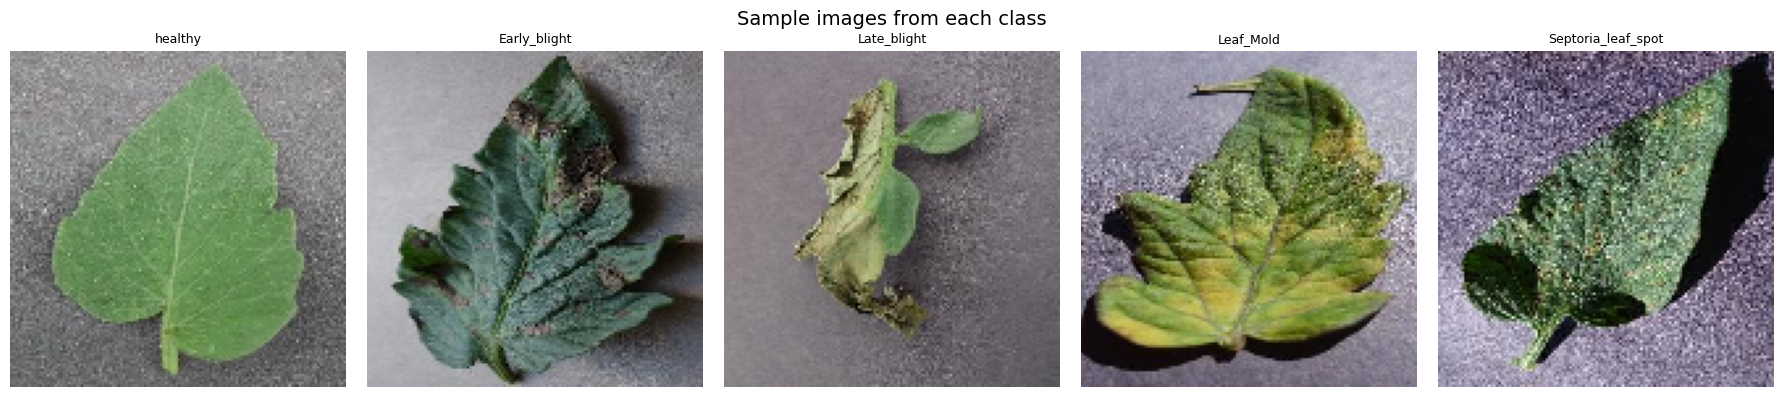

These are the 5 disease types our model will learn to identify.


In [6]:

from tensorflow.keras.preprocessing import image as keras_image

fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(18, 4))
fig.suptitle("Sample images from each class", fontsize=14)

for i, cls in enumerate(SELECTED_CLASSES):
    # Get the first image in this class folder
    class_folder = f"{SMALL_DATASET}/train/{cls}"
    img_file     = os.listdir(class_folder)[0]
    img_path     = os.path.join(class_folder, img_file)

    # Load and show the image
    img = keras_image.load_img(img_path, target_size=(128, 128))
    axes[i].imshow(img)
    axes[i].set_title(cls.replace("Tomato__", "").replace("Tomato_", ""), fontsize=9)
    axes[i].axis('off')  # hide axis numbers

plt.tight_layout()
plt.show()
print("These are the 5 disease types our model will learn to identify.")



In [7]:
IMG_SIZE   = 128   # all images resized to 128x128 pixels
BATCH_SIZE = 32    # how many images to process at once

# Training generator: with augmentation to improve model robustness
train_datagen = ImageDataGenerator(
    rescale=1./255,        # normalize: divide every pixel by 255
    rotation_range=20,     # randomly rotate image up to 20 degrees
    width_shift_range=0.1, # randomly shift image left/right by 10%
    height_shift_range=0.1,# randomly shift image up/down by 10%
    horizontal_flip=True,  # randomly flip image left-right
    zoom_range=0.1,        # randomly zoom in/out by 10%
)

# Validation generator: NO augmentation (we want real evaluation)
val_datagen = ImageDataGenerator(
    rescale=1./255   # only normalize, no augmentation for validation
)

# Load training images from the train folder
# flow_from_directory automatically reads subfolder names as class labels
train_generator = train_datagen.flow_from_directory(
    f"{SMALL_DATASET}/train",  # path to training images
    target_size=(IMG_SIZE, IMG_SIZE),  # resize every image to 128x128
    batch_size=BATCH_SIZE,     # load 32 images at a time
    class_mode='categorical',  # one-hot encoding for multi-class
)

# Load validation images
val_generator = val_datagen.flow_from_directory(
    f"{SMALL_DATASET}/val",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
)

# Print the class index mapping
print("\nClass label mapping (class name → number):")
for class_name, index in train_generator.class_indices.items():
    print(f"  {index}: {class_name}")


Found 5776 images belonging to 5 classes.
Found 1447 images belonging to 5 classes.

Class label mapping (class name → number):
  0: Tomato_Early_blight
  1: Tomato_Late_blight
  2: Tomato_Leaf_Mold
  3: Tomato_Septoria_leaf_spot
  4: Tomato_healthy


In [8]:
model = keras.Sequential([

    # ── BLOCK 1 ────────────────────────────────────────────
    # Conv2D: 32 filters of size 3×3, detect low-level features
    # activation='relu': ReLU removes negative values (max(0,x))
    # input_shape: first layer needs to know the image shape
    layers.Conv2D(32, (3, 3), activation='relu',
                  input_shape=(IMG_SIZE, IMG_SIZE, 3),
                  padding='same'),
    # BatchNormalization: stabilizes training, faster convergence
    layers.BatchNormalization(),
    # MaxPooling2D: shrinks feature map from 128×128 → 64×64
    # Takes the maximum value in each 2×2 region
    layers.MaxPooling2D(2, 2),

    # ── BLOCK 2 ────────────────────────────────────────────
    # 64 filters: more filters = detects more complex features
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    # Shrinks 64×64 → 32×32
    layers.MaxPooling2D(2, 2),

    # ── BLOCK 3 ────────────────────────────────────────────
    # 128 filters: detects high-level disease patterns
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    # Shrinks 32×32 → 16×16
    layers.MaxPooling2D(2, 2),

    # ── CLASSIFICATION HEAD ────────────────────────────────
    # Flatten: converts 16×16×128 = 32768 values into a 1D vector
    # This bridges convolutional layers and dense layers
    layers.Flatten(),

    # Dense layer: 256 neurons, fully connected
    layers.Dense(256, activation='relu'),

    # Dropout: randomly turns off 50% of neurons during training
    # This prevents overfitting (memorizing training images)
    layers.Dropout(0.5),

    # Output layer: one neuron per class
    # softmax converts raw numbers to probabilities (all sum to 1.0)
    # e.g. [0.02, 0.85, 0.05, 0.04, 0.04] → class 1 (Early Blight)
    layers.Dense(NUM_CLASSES, activation='softmax'),
])

# ── COMPILE ───────────────────────────────────────────────
# optimizer='adam': Adam automatically adjusts the learning rate
# loss='categorical_crossentropy': standard loss for multi-class problems
# metrics=['accuracy']: track accuracy during training
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Print model summary: shows all layers and parameter count
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,484,293 (32.37 MB)

 Trainable params: 8,483,845 (32.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [9]:
callbacks = [
    # ReduceLROnPlateau: if val_loss stops improving for 3 epochs,
    # cut the learning rate by half. Helps fine-tune the model.
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        verbose=1
    ),
    # EarlyStopping: if val_loss stops improving for 5 epochs,
    # stop training early to save time and prevent overfitting.
    # restore_best_weights: reverts to the best epoch's weights.
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
]

print("Starting training... This may take 5-15 minutes on Colab GPU.")
print("Enable GPU: Runtime → Change runtime type → T4 GPU\n")

EPOCHS = 15  # maximum number of epochs (EarlyStopping may stop earlier)

history = model.fit(
    train_generator,          # training images
    epochs=EPOCHS,            # number of training loops
    validation_data=val_generator,  # validation images
    callbacks=callbacks,      # automatic learning rate + early stop
    verbose=1                 # show progress for each epoch
)

print("\nTraining complete!")

Starting training... This may take 5-15 minutes on Colab GPU.
Enable GPU: Runtime → Change runtime type → T4 GPU

Epoch 1/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 49s 199ms/step - accuracy: 0.6252 - loss: 2.0008 - val_accuracy: 0.2640 - val_loss: 28.4111 - learning_rate: 0.0010
Epoch 2/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 30s 165ms/step - accuracy: 0.6868 - loss: 0.8241 - val_accuracy: 0.4679 - val_loss: 5.4111 - learning_rate: 0.0010
Epoch 3/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 32s 174ms/step - accuracy: 0.7176 - loss: 0.7525 - val_accuracy: 0.7616 - val_loss: 0.8160 - learning_rate: 0.0010
Epoch 4/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 30s 165ms/step - accuracy: 0.7372 - loss: 0.7016 - val_accuracy: 0.2778 - val_loss: 17.0082 - learning_rate: 0.0010
Epoch 5/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 30s 166ms/step - accuracy: 0.7516 - loss: 0.6628 - val_accuracy: 0.7028 - val_loss: 0.8465 - learning_rate: 0.0010
Epoch 6/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.7727 - loss: 0.6205
Epoch 6: ReduceLROnPl

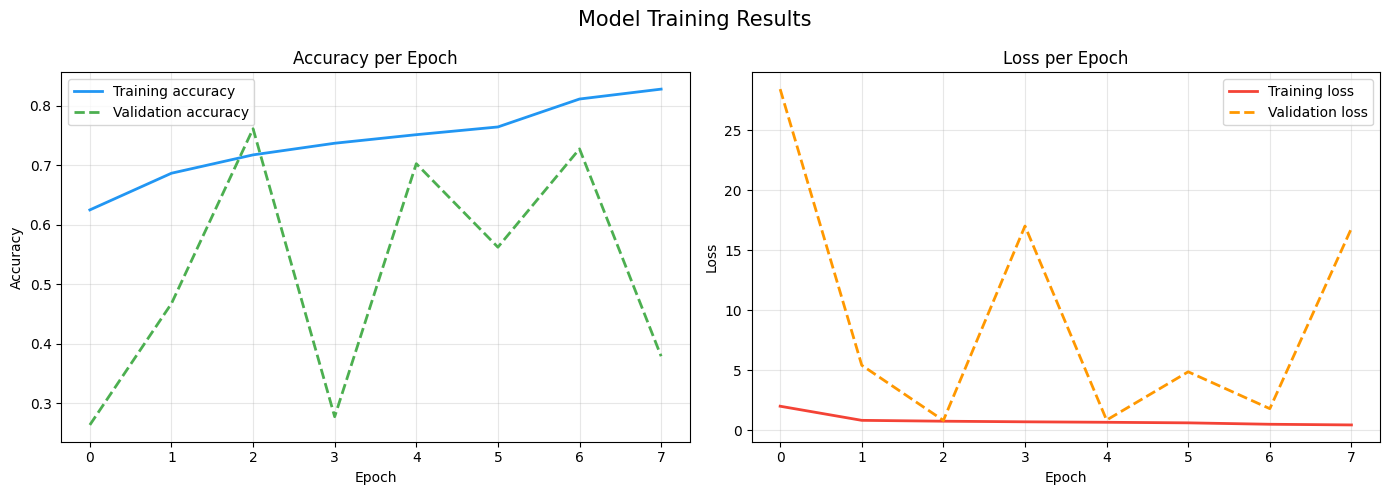

Final Validation Accuracy: 76.16%
Final Validation Loss:     0.8160

Classification Report:
(Precision = how accurate positive predictions are)
(Recall = how many actual positives were found)
(F1 = balance between precision and recall)

                    precision    recall  f1-score   support

      Early_blight       0.16      0.16      0.16       200
       Late_blight       0.26      0.34      0.29       382
         Leaf_Mold       0.13      0.09      0.11       191
Septoria_leaf_spot       0.24      0.18      0.20       355
           healthy       0.22      0.24      0.23       319

          accuracy                           0.22      1447
         macro avg       0.20      0.20      0.20      1447
      weighted avg       0.22      0.22      0.21      1447



In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Model Training Results", fontsize=15)

# ── Left plot: Accuracy ──────────────────────────────────
axes[0].plot(history.history['accuracy'],
             label='Training accuracy', color='#2196F3', linewidth=2)
axes[0].plot(history.history['val_accuracy'],
             label='Validation accuracy', color='#4CAF50',
             linewidth=2, linestyle='--')
axes[0].set_title('Accuracy per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── Right plot: Loss ─────────────────────────────────────
axes[1].plot(history.history['loss'],
             label='Training loss', color='#F44336', linewidth=2)
axes[1].plot(history.history['val_loss'],
             label='Validation loss', color='#FF9800',
             linewidth=2, linestyle='--')
axes[1].set_title('Loss per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ════════════════════════════════════════════════════════════
# CELL 10 — Evaluate the model on validation data
# ════════════════════════════════════════════════════════════
# This gives the final accuracy on images the model NEVER saw.
# This is the real measure of how well the model works.

val_loss, val_accuracy = model.evaluate(val_generator, verbose=0)
print(f"Final Validation Accuracy: {val_accuracy * 100:.2f}%")
print(f"Final Validation Loss:     {val_loss:.4f}")
print()

# Detailed classification report: precision, recall, F1 per class
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Get true labels and predictions for all validation images
val_generator.reset()  # reset generator to start from beginning
y_pred_probs = model.predict(val_generator, verbose=0)  # predicted probabilities
y_pred = np.argmax(y_pred_probs, axis=1)  # predicted class index
y_true = val_generator.classes             # true class indices

# Map index → class name (for readable report)
class_names = list(val_generator.class_indices.keys())
short_names = [c.replace("Tomato__", "").replace("Tomato_", "")
               for c in class_names]

print("Classification Report:")
print("(Precision = how accurate positive predictions are)")
print("(Recall = how many actual positives were found)")
print("(F1 = balance between precision and recall)\n")
print(classification_report(y_true, y_pred, target_names=short_names))


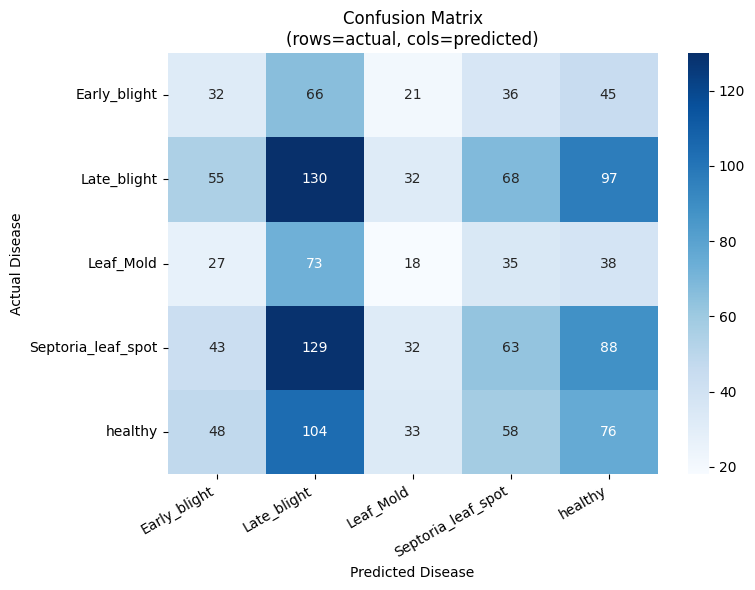

In [11]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm,
            annot=True,         # show numbers inside cells
            fmt='d',            # format as integer
            cmap='Blues',       # blue color scheme
            xticklabels=short_names,
            yticklabels=short_names)
plt.title('Confusion Matrix\n(rows=actual, cols=predicted)')
plt.ylabel('Actual Disease')
plt.xlabel('Predicted Disease')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

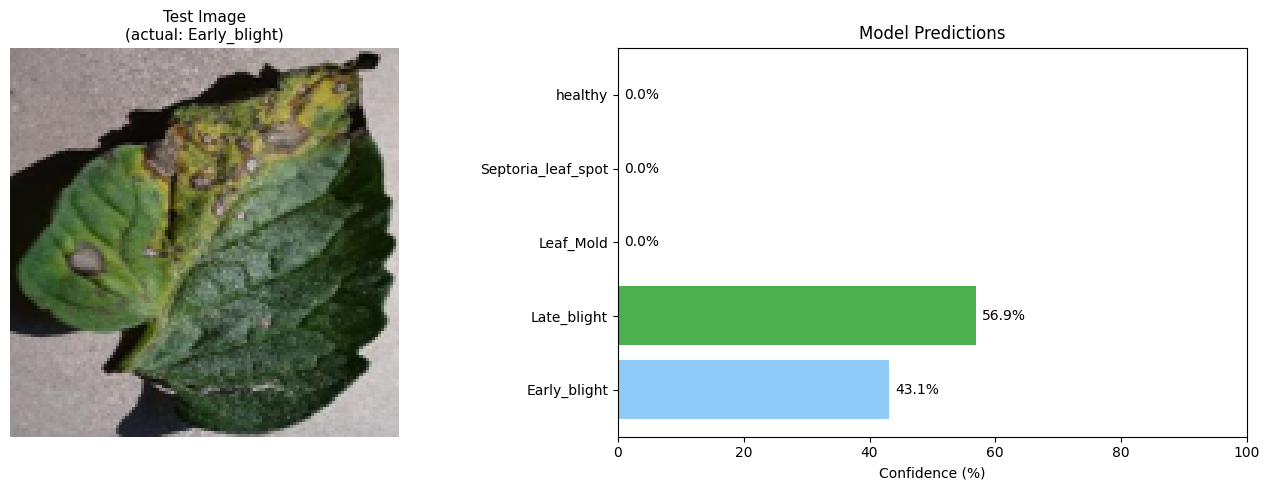

  PLANT DISEASE DETECTION REPORT
  Detected Disease : Late Blight
  Confidence       : 56.9%
  Severity         : High — spreads rapidly
-------------------------------------------------------
  Description:
  Caused by Phytophthora infestans. Shows water-soaked lesions turning brown.
-------------------------------------------------------
  First Aid / Treatment:
  1. Remove and destroy all infected plant parts.
2. Apply chlorothalonil or mancozeb fungicide.
3. Improve drainage around plants.
-------------------------------------------------------
  Prevention:
  Plant in well-drained soil. Use certified disease-free seeds.


In [12]:
from PIL import Image  # PIL = Python Imaging Library

# Disease information dictionary
# This is what your web app will show the user
DISEASE_INFO = {
    "Tomato_healthy": {
        "display_name": "Healthy Tomato",
        "description":  "The tomato plant is healthy with no signs of disease.",
        "first_aid":    "No treatment needed. Continue regular watering and fertilizing.",
        "prevention":   "Maintain proper watering schedule. Ensure good air circulation.",
        "severity":     "None"
    },
    "Tomato_Early_blight": {
        "display_name": "Early Blight",
        "description":  "Caused by Alternaria solani fungus. Shows dark brown spots with yellow rings.",
        "first_aid":    "1. Remove infected leaves immediately.\n"
                        "2. Apply copper-based fungicide.\n"
                        "3. Avoid overhead watering.",
        "prevention":   "Rotate crops. Use resistant varieties. Apply mulch.",
        "severity":     "Moderate"
    },
    "Tomato_Late_blight": {
        "display_name": "Late Blight",
        "description":  "Caused by Phytophthora infestans. Shows water-soaked lesions turning brown.",
        "first_aid":    "1. Remove and destroy all infected plant parts.\n"
                        "2. Apply chlorothalonil or mancozeb fungicide.\n"
                        "3. Improve drainage around plants.",
        "prevention":   "Plant in well-drained soil. Use certified disease-free seeds.",
        "severity":     "High — spreads rapidly"
    },
    "Tomato_Leaf_Miner": {
        "display_name": "Leaf Miner",
        "description":  "Insect larvae tunnel inside leaves creating white winding trails.",
        "first_aid":    "1. Remove heavily infested leaves.\n"
                        "2. Apply neem oil or spinosad insecticide.\n"
                        "3. Use yellow sticky traps to catch adult flies.",
        "prevention":   "Use row covers. Introduce natural predators (parasitic wasps).",
        "severity":     "Low to Moderate"
    },
    "Tomato_Septoria_leaf_spot": {
        "display_name": "Septoria Leaf Spot",
        "description":  "Caused by Septoria lycopersici. Shows small circular spots with dark borders.",
        "first_aid":    "1. Remove infected lower leaves first.\n"
                        "2. Apply mancozeb or copper fungicide.\n"
                        "3. Water at the base, not on leaves.",
        "prevention":   "Avoid overhead irrigation. Crop rotation every 2-3 years.",
        "severity":     "Moderate"
    },
}

def predict_disease(image_path):
    """
    Takes an image path, preprocesses it, runs the model,
    and returns the predicted disease with all details.
    """
    # Step 1: Load the image and resize to 128×128
    img = Image.open(image_path).convert('RGB')  # ensure 3 channels (RGB)
    img_resized = img.resize((IMG_SIZE, IMG_SIZE))

    # Step 2: Convert to NumPy array and normalize
    img_array = np.array(img_resized)   # shape: (128, 128, 3)
    img_array = img_array / 255.0       # normalize to 0-1 range

    # Step 3: Add batch dimension
    # model.predict() expects shape (batch_size, height, width, channels)
    # Our single image needs to become (1, 128, 128, 3)
    img_array = np.expand_dims(img_array, axis=0)  # shape: (1, 128, 128, 3)

    # Step 4: Get predictions (probabilities for each class)
    predictions = model.predict(img_array, verbose=0)
    # predictions shape: (1, 5) → e.g. [[0.02, 0.85, 0.05, 0.04, 0.04]]

    # Step 5: Get the class with highest probability
    predicted_index = np.argmax(predictions[0])    # e.g. 1
    confidence      = predictions[0][predicted_index] * 100  # e.g. 85.0%

    # Step 6: Get the class name from the index
    # Reverse the class_indices dict: {0: 'class_name', 1: ...}
    index_to_class = {v: k for k, v in train_generator.class_indices.items()}
    predicted_class = index_to_class[predicted_index]

    return predicted_class, confidence, predictions[0]


# Pick a random validation image to test
test_class_folder = f"{SMALL_DATASET}/val/{SELECTED_CLASSES[1]}"
test_images = os.listdir(test_class_folder)
test_img_path = os.path.join(test_class_folder, test_images[0])

# Run prediction
predicted_class, confidence, all_probs = predict_disease(test_img_path)
disease_info = DISEASE_INFO[predicted_class]

# Display the image and results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: show the leaf image
img_display = Image.open(test_img_path).resize((128, 128))
axes[0].imshow(img_display)
axes[0].set_title(f"Test Image\n(actual: {SELECTED_CLASSES[1].replace('Tomato__','').replace('Tomato_','')})",
                  fontsize=11)
axes[0].axis('off')

# Right: show probability bar chart
short_class_names = [c.replace("Tomato__","").replace("Tomato_","")
                     for c in class_names]
colors = ['#4CAF50' if i == np.argmax(all_probs) else '#90CAF9'
          for i in range(len(all_probs))]
axes[1].barh(short_class_names, all_probs * 100, color=colors)
axes[1].set_xlabel('Confidence (%)')
axes[1].set_title('Model Predictions')
axes[1].set_xlim(0, 100)
for i, v in enumerate(all_probs * 100):
    axes[1].text(v + 1, i, f'{v:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.show()

# Print the disease report
print("=" * 55)
print(f"  PLANT DISEASE DETECTION REPORT")
print("=" * 55)
print(f"  Detected Disease : {disease_info['display_name']}")
print(f"  Confidence       : {confidence:.1f}%")
print(f"  Severity         : {disease_info['severity']}")
print("-" * 55)
print(f"  Description:\n  {disease_info['description']}")
print("-" * 55)
print(f"  First Aid / Treatment:\n  {disease_info['first_aid']}")
print("-" * 55)
print(f"  Prevention:\n  {disease_info['prevention']}")
print("=" * 55)



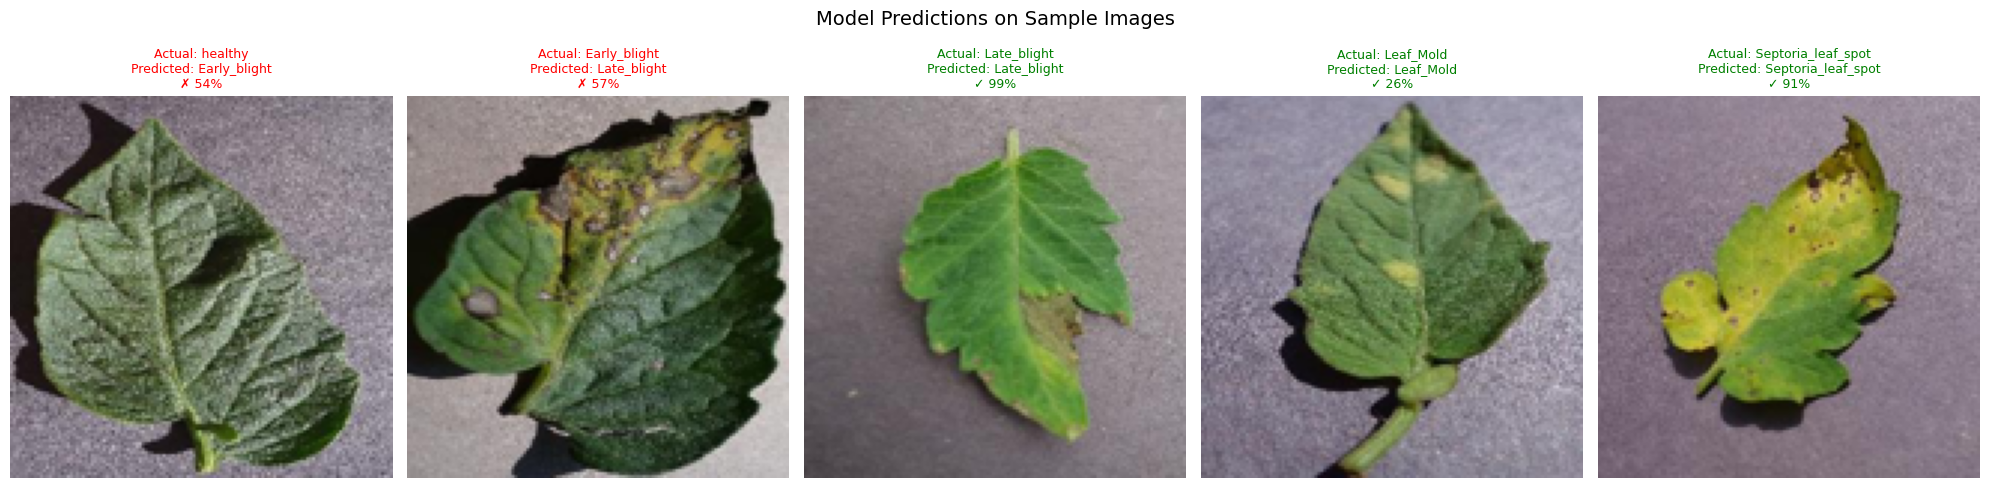

Model saved as: plant_disease_model.h5
Model size: 97.2 MB
Class indices saved as: class_indices.json
  Model accuracy: 76.2%
  Classes detected: 5
  Saved model: plant_disease_model.h5
  Next step: Build the Streamlit web app!


In [13]:
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(20, 5))
fig.suptitle("Model Predictions on Sample Images", fontsize=14, y=1.02)

for i, cls in enumerate(SELECTED_CLASSES):
    class_val_folder = f"{SMALL_DATASET}/val/{cls}"
    sample_images    = os.listdir(class_val_folder)
    sample_img_path  = os.path.join(class_val_folder, sample_images[0])

    predicted_class, confidence, _ = predict_disease(sample_img_path)
    actual_short     = cls.replace("Tomato__", "").replace("Tomato_", "")
    predicted_short  = predicted_class.replace("Tomato__","").replace("Tomato_","")

    # Green title if correct, red if wrong
    is_correct   = (predicted_class == cls)
    title_color  = 'green' if is_correct else 'red'
    status_emoji = "✓" if is_correct else "✗"

    img_display = Image.open(sample_img_path).resize((128, 128))
    axes[i].imshow(img_display)
    axes[i].set_title(
        f"Actual: {actual_short}\nPredicted: {predicted_short}\n"
        f"{status_emoji} {confidence:.0f}%",
        color=title_color, fontsize=9
    )
    axes[i].axis('off')

plt.tight_layout()
plt.show()


# ════════════════════════════════════════════════════════════
# CELL 14 — Save the trained model
# ════════════════════════════════════════════════════════════
# Save the model so we can use it later in the web app.
# The .h5 file contains all the learned weights.

MODEL_SAVE_PATH = "plant_disease_model.h5"
model.save(MODEL_SAVE_PATH)
print(f"Model saved as: {MODEL_SAVE_PATH}")
print(f"Model size: {os.path.getsize(MODEL_SAVE_PATH) / (1024*1024):.1f} MB")

# Also save the class names in order
# We need this in the web app to map predictions back to class names
import json
class_indices = train_generator.class_indices  # {'class_name': index, ...}
# Flip it to {index: 'class_name'}
index_to_class = {str(v): k for k, v in class_indices.items()}
with open("class_indices.json", "w") as f:
    json.dump(index_to_class, f, indent=2)
print("Class indices saved as: class_indices.json")

# Download both files to your computer
# (Uncomment the lines below to download in Colab)
# from google.colab import files
# files.download(MODEL_SAVE_PATH)
# files.download("class_indices.json")

print(f"  Model accuracy: {val_accuracy*100:.1f}%")
print(f"  Classes detected: {NUM_CLASSES}")
print(f"  Saved model: {MODEL_SAVE_PATH}")
print("  Next step: Build the Streamlit web app!")
print("="*55)

In [18]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image


In [19]:
# Build model once (important for Keras 3)

dummy = np.zeros((1, IMG_SIZE, IMG_SIZE, 3), dtype=np.float32)
_ = model(dummy)

In [20]:
LAST_CONV_LAYER = "conv2d_2"

In [21]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):

    # Build grad model
    grad_model = tf.keras.Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.outputs[0]
        ]
    )

    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(img_array, training=False)

        pred_index = tf.argmax(predictions[0])

        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap, 0)

    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy()

In [22]:
def display_gradcam(image_path, heatmap):

    img = cv2.imread(image_path)

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    heatmap = cv2.resize(
        heatmap,
        (img.shape[1], img.shape[0])
    )

    heatmap = np.uint8(255 * heatmap)

    heatmap = cv2.applyColorMap(
        heatmap,
        cv2.COLORMAP_JET
    )

    heatmap = cv2.cvtColor(
        heatmap,
        cv2.COLOR_BGR2RGB
    )

    superimposed = cv2.addWeighted(
        img,
        0.6,
        heatmap,
        0.4,
        0
    )

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(superimposed)
    plt.title("Grad-CAM")
    plt.axis("off")

    plt.show()

In [23]:
test_folder = os.path.join(
    SMALL_DATASET,
    "val",
    SELECTED_CLASSES[0]
)

test_img_path = os.path.join(
    test_folder,
    os.listdir(test_folder)[0]
)

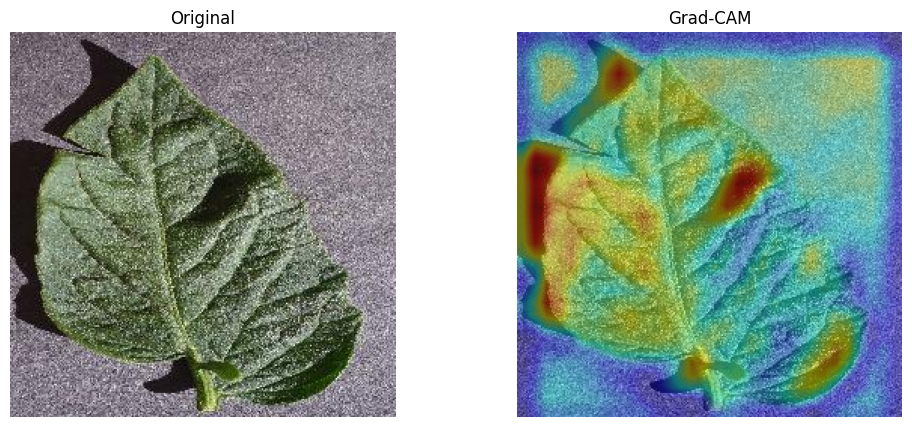

In [24]:
img = Image.open(test_img_path).convert("RGB")

img = img.resize((IMG_SIZE, IMG_SIZE))

img_array = np.array(img).astype("float32")/255.0

img_array = np.expand_dims(img_array, axis=0)

heatmap = make_gradcam_heatmap(
    img_array,
    model,
    LAST_CONV_LAYER
)

display_gradcam(
    test_img_path,
    heatmap
)